This notebook details MicroGrad (Micro-Gradient). It is the foundational math to understand how neural networks learn via backpropagation.

In [1]:
# Imports
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5
f(3.0)

20.0

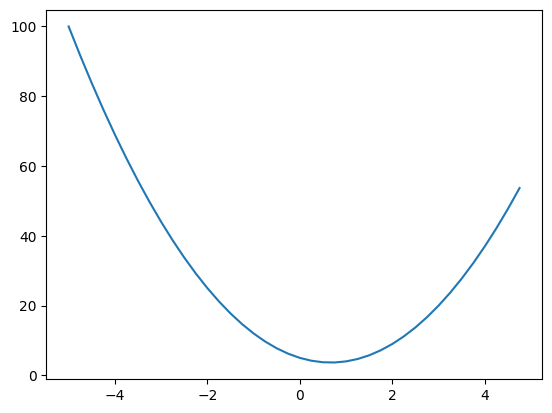

In [3]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

- Definition of a derivative: (f(x+h)-f(x))/h as h approaches 0

- Understand in a given function how it's value and slopes change as an infinitesmal 'h' value is incremented on any variable
- In the case below, if a is incremented by h, d decreases (since the a*b product becomes more negative)
- If b is incremented by h, d increases, as the a*b product becomes less negative
- If c is incremented by h, d also increases

In [4]:
h = 0.000001
x = 2/3
a = 2.0
b = -3.0
c = 10.0
d= a * b + c

d1 = a * b + c
c += h
d2 = a * b + c

print ('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 4.000000999999999
slope 0.9999999992515995


Neural networks are ultimately extremely large mathematical expressions. Because of how large they are, data structures are needed to maintain and work with them.
- Value: simple keeps track of a scalar value
    - __init__: constructor that initializes the value's data, its children (will be helpful in backprop), the operation used to get it, a label (for visualization), and grad
    - __repr__: initializes what gets represented/printed
    - __add__: method that takes an object of class 'value' (self parameter), and another value, and multiplies them
    - __mul__: method that takes an object of class 'value' (self parameter), and another value, and multiplies them
    - tanh: just an activation function (used in the neuron walkthrough further down this notebook)
    - There is also a backward method defined within some methods (empty function in init, as thats a leaf node, but defined in __add__, __mul__, and tanh/any other activation function).
        - The backward method is meant to automatically compute the gradients at each node vie backpropagation. The following cells detail how backprop works, but this method automates it.
- 

In [112]:
class Value:

    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

Below is a visualization script. Note that the rectangular boxes are objects (not the round ones)

In [9]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s |  data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

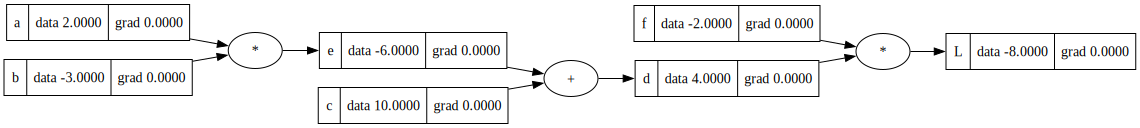

In [10]:
draw_dot(L)

In [ ]:
def lol():
    # Keeping all values except for 1 constant, we can find the slope/derivative of L wrt any variable.
    # In this case, we are finding the derivative of L wrt d

    h = 0.0001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L.data += h
    L2 = L.data

    print((L2 - L1)/h)

lol() # Computes the derivative of L wrt itself (=1)

0.9999999999976694


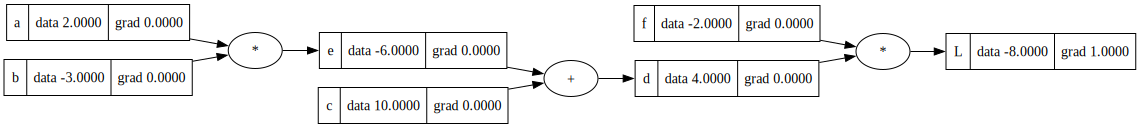

In [11]:
L.grad = 1.0
draw_dot(L)

In [12]:
def lol():
    # Keeping all values except for 1 constant, we can find the slope/derivative of L wrt any variable.
    # In this case, we are finding the derivative of L wrt d

    h = 0.0001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol() # Computes the derivative of L wrt d (=-2)

-1.9999999999953388


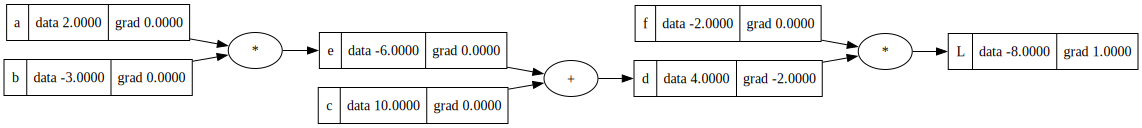

In [14]:
d.grad = -2.0
draw_dot(L)

In [15]:
def lol():
    # Keeping all values except for 1 constant, we can find the slope/derivative of L wrt any variable.
    # In this case, we are finding the derivative of L wrt f

    h = 0.0001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0 + h, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol() # Computes the derivative of L wrt f (=4)

3.9999999999995595


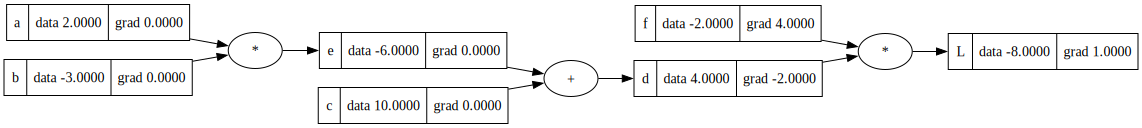

In [16]:
f.grad = 4.0
draw_dot(L)

Now, we must find figure out how a variable like c affects L (multistep derivative).

d = c + e
dd/dc = 1 (basic calculus but proof below)

dd/dc ≈ ((c + e + h) - (c + e))/h
      ≈ (c + e + h - C - e)/h
      ≈ h/h
      ≈ 1
dd/de ≈ 1 (by symmetry) 


To find dL/dc, we must use the chain rule --> dx/dz = dx/dy * dy/dz

dL/dc = dL/dd * dd/dc

c.grad = d.grad * 1 (derived above)
e.grad = d.grad * 1 (also derived above)
both   = -2

In [18]:
def lol():
    # Keeping all values except for 1 constant, we can find the slope/derivative of L wrt any variable.
    # In this case, we are finding the derivative of L wrt e

    h = 0.0001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    e.data += h
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol() # Computes the derivative of L wrt e (=-2)
      # Note that either, e or c could have been incremented and the result would be -2 either way since d = e + c (dd/dc = dd/de = 1)

-1.9999999999953388


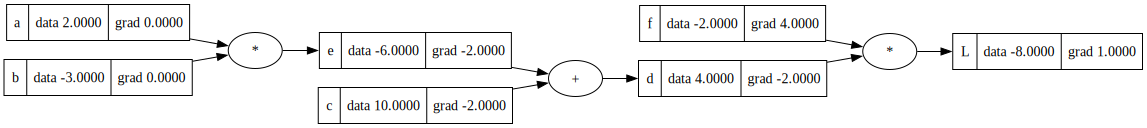

In [17]:
c.grad = -2.0
e.grad = -2.0
draw_dot(L)

dL/da = dL/de * de/da (dL/de is the same as e.grad which we found in the previous step to be -2.0)

e = a * b
de/da = b (basic calculus)
b = -3

dL/da = e.grad * (-3)
      = (-2) * (-3)
      = 6

dL/da = a.grad = 6

Check with lol() by incrementing a only:

In [19]:
def lol():
    # Keeping all values except for 1 constant, we can find the slope/derivative of L wrt any variable.
    # In this case, we are finding the derivative of L wrt a

    h = 0.0001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 + h, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol() # Computes the derivative of L wrt a (=6)

6.000000000021544


dL/db = dL/de * de/db (dL/de is the same as e.grad which we found in the previous step to be -2.0)

e = a * b
de/db = a (basic calculus)
a = 2

dL/db = e.grad * (2)
      = (-2) * (2)
      = -4

dL/db = b.grad = -4

Check with lol() by incrementing a only:

In [20]:
def lol():
    # Keeping all values except for 1 constant, we can find the slope/derivative of L wrt any variable.
    # In this case, we are finding the derivative of L wrt b

    h = 0.0001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0 + h, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol() # Computes the derivative of L wrt b (=6)

-4.000000000008441


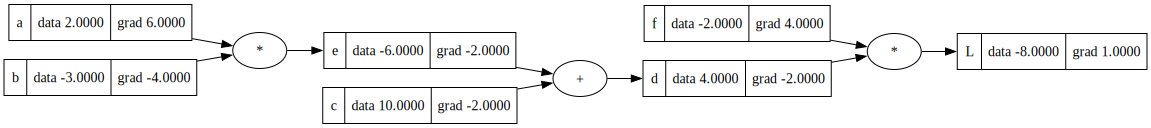

In [24]:
a.grad = 6
b.grad = -4
draw_dot(L)

This marks the end of the manual backpropagation walthrough. Here are the main steps/concepts:

1. Get the derivative of the final object wrt itself.
2. Keep stepping back along the tree, and calculate the local gradient at each node using the chain rule (multiplying the derivative, d?/dnode of it's expression by the recursive gradient, ?.grad until that point.)
    - For example, L.grad = dL/dL = 1 --> d.grad = dL/dd = -2 (basic calculus) --> then to find e.grad, e.grad = d.grad * dd/de, and so on.

Lets say we want L to go up. To do this, we need to adjust each of the leaf nodes in the direction of their gradients.

In [30]:
# Adjust the gradients
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

# Rerun the forward pass
e = a * b
d = e + c
L = d * f

# With these new changes to the leaf nodes, L (L.data) should be more positive
print(L.data)

-7.147944363266539


Now, Lets look into the anatomy of a neuron (https://cs231n.github.io/assets/nn1/neuron_model.jpeg). In general the neuron follows a few steps:

1. Input data 1 multiplied by weight 1 (at the synapse) at every synapse. For example, if there are 3 synapses, that means there are 3 input data pieces.
2. In the cell body, all products are summed, and added with a neuron-unique bias (the inert trigger-happiness of that individual neuron).
3. Result is processed with an activation function (usually some kind of squashing function like a sigmoid or tanh function).

See tanh below:

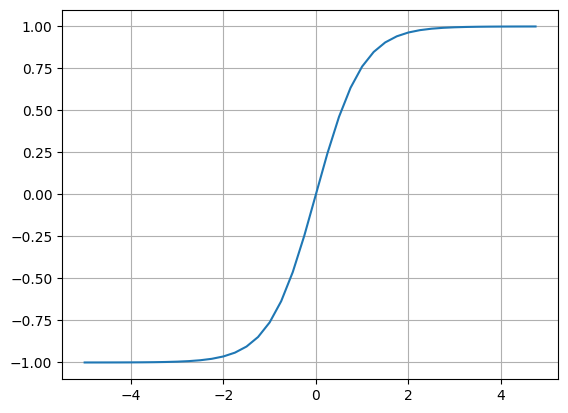

In [35]:
plt.plot(np.arange(-5, 5, 0.25), np.tanh(np.arange(-5, 5, 0.25)))
plt.grid()

Below is a simulation of what goes on inside a neuron:

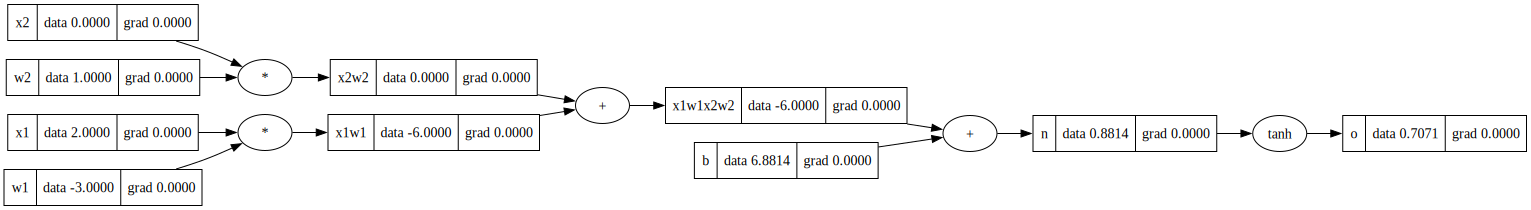

In [88]:
# Initialize the values being used in the neuron (input values, weights, and bias)
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b') # This value is chosen so that the output of the neuron is 1 (since tanh(1) = 0.7615941559557649)

# Perform the operations of the neuron (multiple each input by its weight, add them, and add the bias)
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

Now that we have a visualization of a real neuron (input data, weights, bias, and activation), lets backpropagate through:

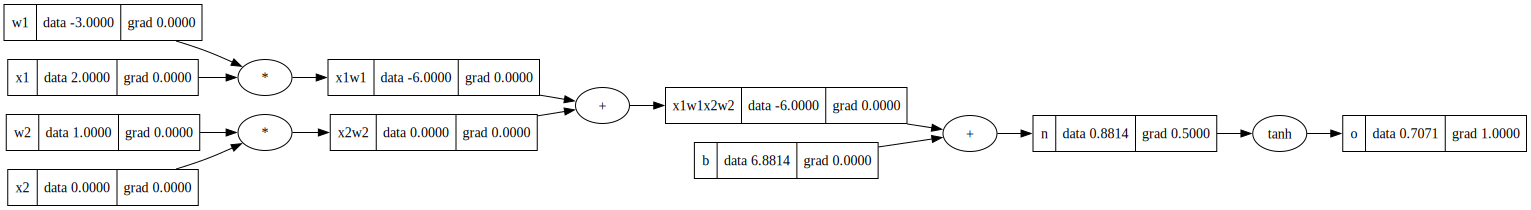

In [47]:
o.grad = 1.0 # Gradient of the end object will be 1 since do/do = 1
# do/dn = 1 - tanh^2(n) (derivative of tanh)
# do/dn = 1 - tanh(n)**2 --> tanh(n) = o (specifically, o.data). Therefore:
# do/dn = 1 - o.data**2
# n.grad = do/dn
n.grad = 1 - o.data**2
n.grad = 0.5
draw_dot(o)

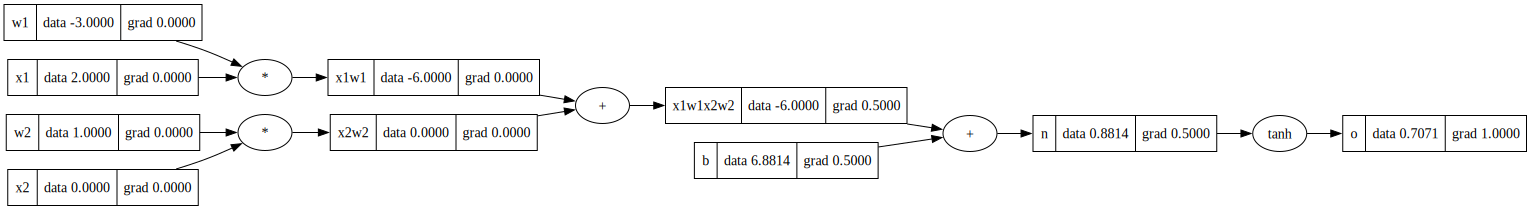

In [ ]:
# Operation: x1w1x2w2 + b = n
# dn/db = 1
# b.grad = dn/db * n.grad = 1 * 0.5 = 0.5
b.grad = 0.5
# dn/dx1w1x2w2 = 1
# x1w1x2w2.grad = dn/dx1w1x2w2 * n.grad = 1 * 0.5 = 0.5
x1w1x2w2.grad = 0.5
draw_dot(o)

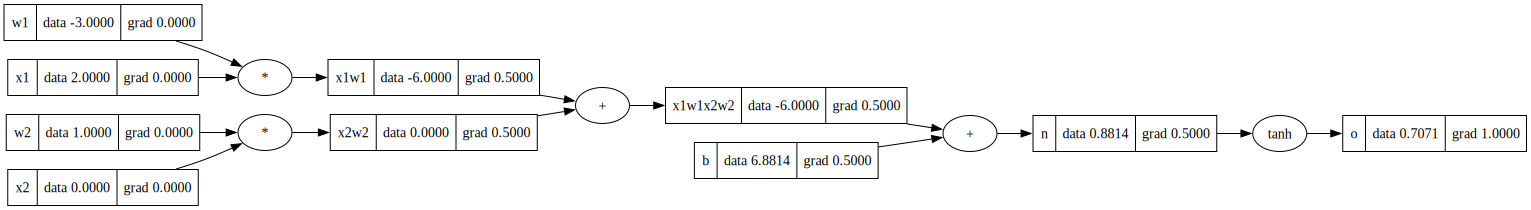

In [51]:
# Operation: x1w1 + x2w2 = x1w1x2w2
# dx1w1x2w2/dx1w1 = 1
# x1w1.grad = dx1w1x2w2/dx1w1 * x1w1x2w2.grad = 1 * 0.5 = 0.5
x1w1.grad = 0.5
# dx1w1x2w2/dx2w2 = 1
# x2w2.grad = dx1w1x2w2/dx2w2 * x1w1x2w2.grad = 1 * 0.5 = 0.5
x2w2.grad = 0.5
draw_dot(o)

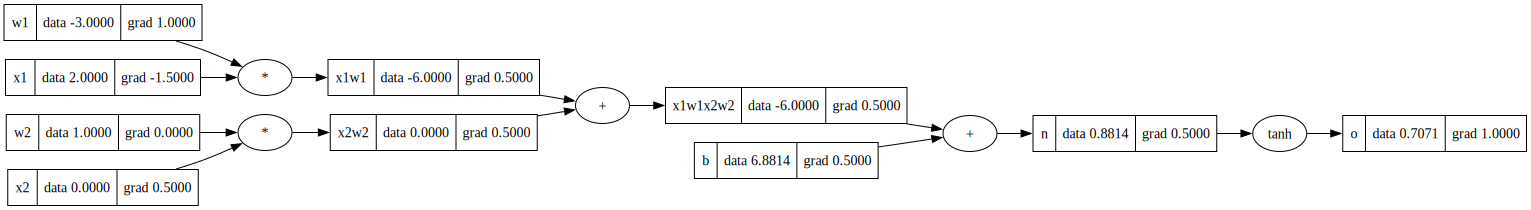

In [52]:
# Operation: x1 * w1 = x1w1
# dx1w1/dx1 = w1 (w1.data)
# x1.grad = w1.data * x1w1.grad
x1.grad = -1.5
# dx1w1/dw1 = x1 (x1.data)
# w1.grad = x1.data * x1w1.grad
w1.grad = 1.0

# Operation: x2 * w2 = x2w2
# dx2w2/dx2 = w2 (w2.data)
# x2.grad = w2.data * x2w2.grad
x2.grad = 0.5
# dx2w2/dw2 = x2 (x2.data)
# w2.grad = x2.data * x2w2.grad
w2.grad = 0.0

draw_dot(o)

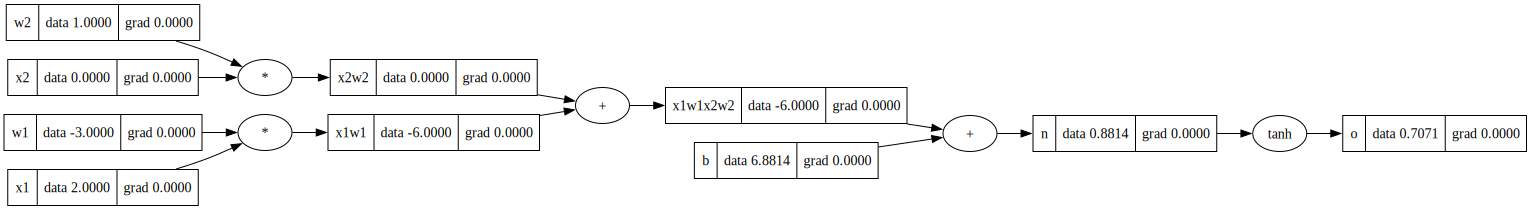

In [89]:
# Initialize the values being used in the neuron (input values, weights, and bias)
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b') # This value is chosen so that the output of the neuron is 1 (since tanh(1) = 0.7615941559557649)

# Perform the operations of the neuron (multiple each input by its weight, add them, and add the bias)
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

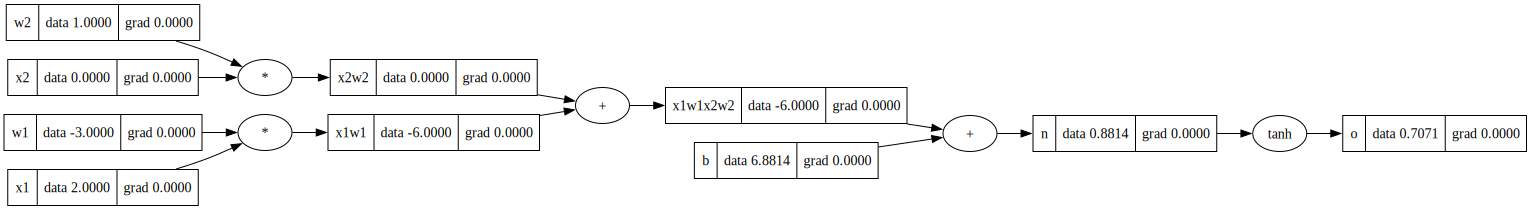

In [90]:
o._backward()
draw_dot(o) # This results in o.grad still being 0 despite that it should actually be 1.
# As a base case, the gradient at o must be initialized to 1

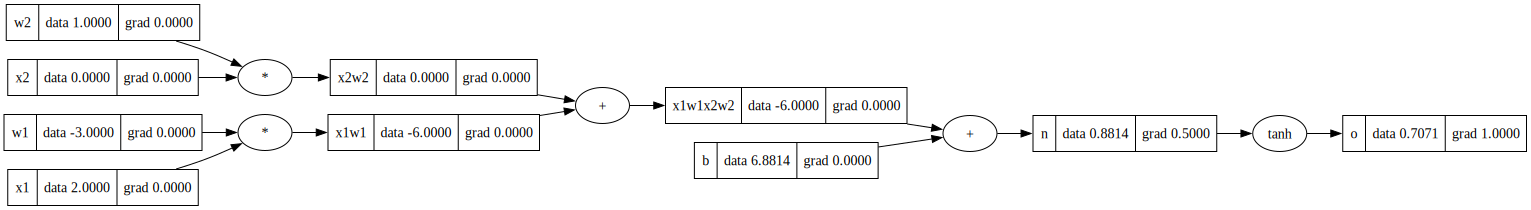

In [91]:
o.grad = 1.0
o._backward()
draw_dot(o)

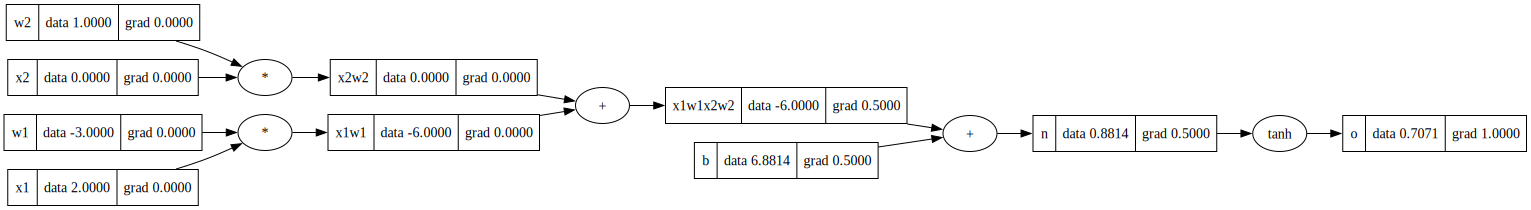

In [92]:
n._backward()
draw_dot(o)

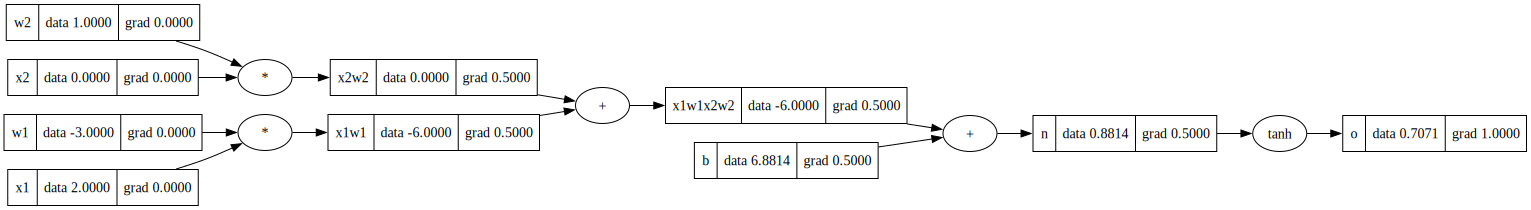

In [93]:
x1w1x2w2._backward()
draw_dot(o)

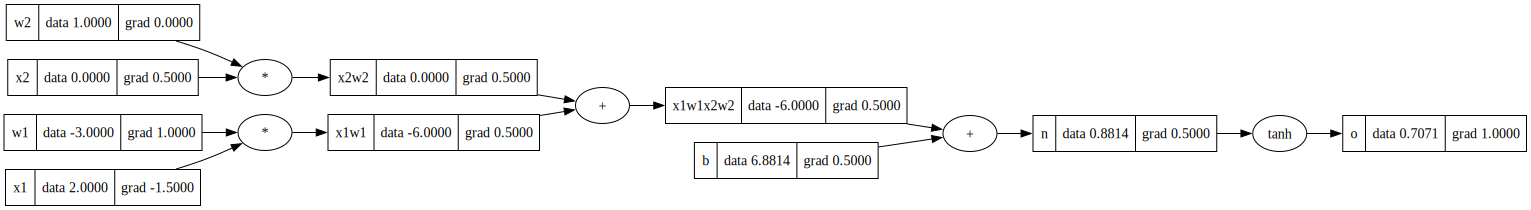

In [94]:
x1w1._backward()
x2w2._backward()
draw_dot(o)

Something to notice about backprop: We need to start at the end of the "expression graph". To help with this, we topologically sort nodes.

In [98]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

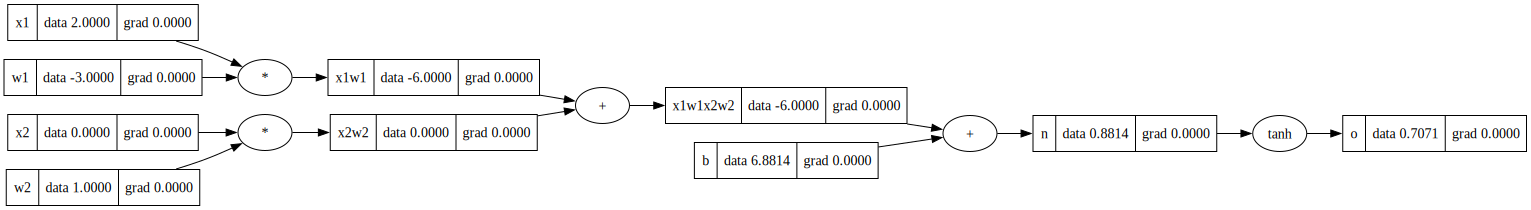

In [110]:
# Reset everything again

# Initialize the values being used in the neuron (input values, weights, and bias)
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b') # This value is chosen so that the output of the neuron is 1 (since tanh(1) = 0.7615941559557649)

# Perform the operations of the neuron (multiple each input by its weight, add them, and add the bias)
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

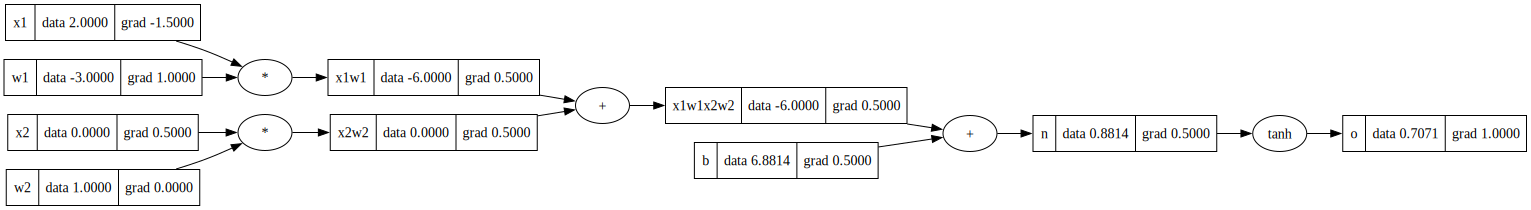

In [ ]:
# Build the topological order of the graph
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)


# Set initial condition to commence backpropagation
o.grad = 1.0

# Backpropagate through the graph in reverse topological order
for node in reversed(topo):
    node._backward()

draw_dot(o)

This is such a mess to do though. So instead, we have added a backwards method at the root level of the value class which includes the building of the topological order, starting node gradient initialization, and _backward calls for each node in the reversed topological order. So now, instead of doing everything in the cell above, we can just call o.backward().

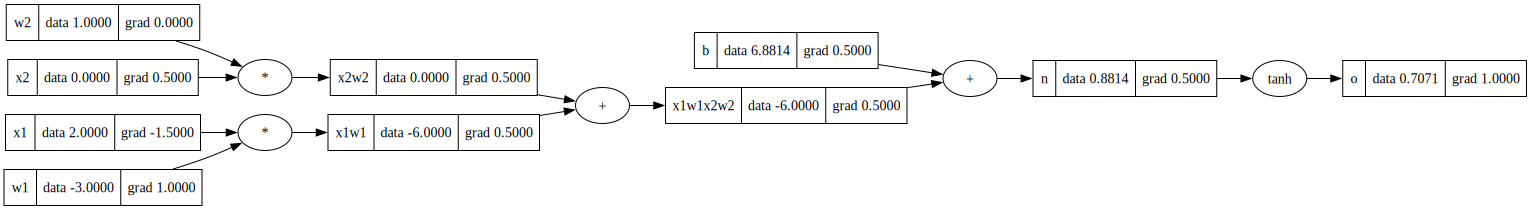

In [113]:
# Reset everything again

# Initialize the values being used in the neuron (input values, weights, and bias)
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b') # This value is chosen so that the output of the neuron is 1 (since tanh(1) = 0.7615941559557649)

# Perform the operations of the neuron (multiple each input by its weight, add them, and add the bias)
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


# Instead of topologically sorting initializing o.grad, and manually stepping backwards for each node:
o.backward()

draw_dot(o)

Everything works thus far, but there is actually a bug in the code.

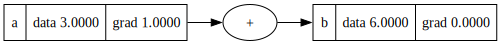

In [ ]:
a = Value(data=3.0, label='a')
b = a + a; b.label = 'b'
a.grad = 1.0
a._backward()
draw_dot(b)
# In the visualization, there are actually 2 arrows pointing at the '+' operator.
# The problem is that in backpropagating, both child nodes are 'a', and are treated as the same node, and get overriden

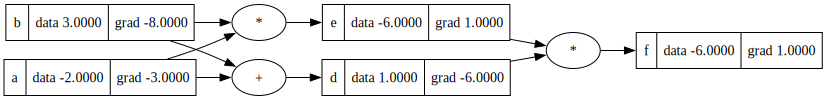

In [128]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a + b; d.label = 'd'
e = a * b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)

# In this example, f backpropagates to d, then to e. So far so good.
# Next, d backpropagates to b, then to a. This is fine.
# Next, e backpropagates to b then to a. In doing this, it just overrides the values attained from backpropagation at node d.

The solution to this issue? Gradients must accululate, not just be assigned values. Right now, in the Value class definition, the nexted backward methods reassign self.grad and other.grad values. Instead, they should be added ('=' becomes '+=').

In [129]:
class Value:

    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    

# a = Value(2.0, label = 'a')
# b = Value(-3.0, label = 'b')
# c = Value(10.0, label = 'c')
# e = a * b; e.label = 'e'
# d = e + c; d.label = 'd'
# f = Value(-2.0, label = 'f')
# L = d * f; L.label = 'L'

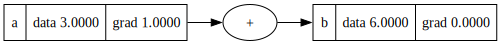

In [130]:
# Now, try again:

a = Value(data=3.0, label='a')
b = a + a; b.label = 'b'
a.grad = 1.0
a._backward()
draw_dot(b)

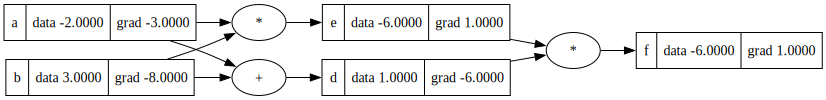

In [135]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a + b; d.label = 'd'
e = a * b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)

# In this example, f backpropagates to d, then to e. So far so good.
# Next, d backpropagates to b, then to a. This is fine.
# Next, e backpropagates to b then to a. In doing this, it just overrides the values attained from backpropagation at node d.

To make things easier in the future:
1. 

In [151]:
class Value:

    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # Convert to Value FIRST
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # Convert to Value FIRST
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other): # This allows for exponentiating a Value object to a non-Value object (e.g. a float) without error. For eg. a ** 2 wouldnt work, so python would call a.__pow__(2) to try to perform the exponentiation
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): # This allows for multiplying a Value object to a non-Value object (e.g. a float) without error. For eg. 2 * a wouldnt work, so python would call a.__rmul__(2) to try to perform the multiplication
        return self * other

    def __truediv__(self, other): # This allows for dividing a Value object to a non-Value object (e.g. a float) without error. For eg. a / 2 wouldnt work, so python would call a.__truediv__(2) to try to perform the division
        return self * (other**-1)
    
    def __neg__(self): # This allows for negating a Value object without error. For eg. -a wouldnt work, so python would call a.__neg__() to try to perform the negation
        return self * -1
    
    def __sub__(self, other): # This allows for subtracting a Value object to a non-Value object (e.g. a float) without error. For eg. a - 2 wouldnt work, so python would call a.__sub__(2) to try to perform the subtraction
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    

# a = Value(2.0, label = 'a')
# b = Value(-3.0, label = 'b')
# c = Value(10.0, label = 'c')
# e = a * b; e.label = 'e'
# d = e + c; d.label = 'd'
# f = Value(-2.0, label = 'f')
# L = d * f; L.label = 'L'

In [152]:
A = Value(2.0)
B = Value(3.0)
A / B

Value(data=0.6666666666666666)

Now that we made those extra class edits to the value class definition, we do not need to say tanh, we can break it into a regular expression (tanh(x) = (e^(2x)-1)/e^(2x)+1)

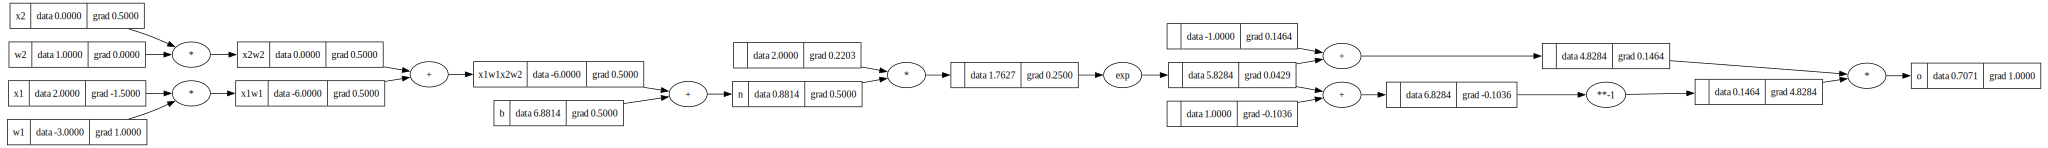

In [155]:
# Reset everything again

# Initialize the values being used in the neuron (input values, weights, and bias)
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b') # This value is chosen so that the output of the neuron is 1 (since tanh(1) = 0.7615941559557649)

# Perform the operations of the neuron (multiple each input by its weight, add them, and add the bias)
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# ---
e = (2*n).exp()
o = (e-1)/(e+1)
# ---
o.label = 'o'
o.backward()
draw_dot(o)

The above representation breaks down tanh into its elementary steps. We define a node 'e', which is e^(2x) or n in this case since n is the node being tanh'd. Tanh = ('e'+1)/('e'-1).
- You can see in the visualization that the first step of tanh is multiplying n by 2 (to get 2n).
- The resulting node is then raised to the power of e (exp) to get 'e'
- then for the next step, 'e' is evaluated alongside +1 and -1 to get ('e'+1) and ('e'-1)
- ('e'+1) is true-div'd by raising to the power of -1.
- Finally, the 2 expressions are multiplied: ('e'-1) * [1/('e'+1)] to get the same answer as tanh.

We are now going to start PyTorch fundamentals. With PyTorch, we can do everything we did with the Value class type, but in tensors.
- A tensor is an n-sized array. See the cells below.

In [176]:
import torch
import random

In [164]:
torch.tensor([[1, 2, 3], [4, 5, 6]]) # Creating a tensor of shape (2, 3) with the values [[1, 2, 3], [4, 5, 6]]
# You can check shape with .shape and dtype with .dtype

tensor([[1, 2, 3],
        [4, 5, 6]])

In [175]:
# Define values (instead of the class value, we are using PyTorch, we they are tensors)
# Must specify requires_grad for each, as PyTorch automatically assumes they are leaf nodes, and do not need gradient tracking
x1 = torch.Tensor([2.0]) ; x1.requires_grad = True
x2 = torch.Tensor([0.0]) ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]) ; w1.requires_grad = True
w2 = torch.Tensor([1.0]) ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]) ; b.requires_grad = True

# Forward pass to compute data values
x1w1 = x1 * w1
x2w2 = x2 * w2
n = x1w1 + x2w2
o = n + b
p = torch.tanh(o)

# Backward pass to compute gradients
p.backward()

# Specify .item() to get only the value, otherwise the tensor is returned
# Specify .grad if you want the gradient, otherwise the data value is returned by default
print('p: ', p)
print('x1.grad: ', x1.grad.item())
print('x2.grad: ', x2.grad.item())
print('w1.grad: ', w1.grad.item())
print('w2.grad: ', w2.grad.item())

p:  tensor([0.7071], grad_fn=<TanhBackward0>)
x1.grad:  -1.5000003576278687
x2.grad:  0.5000001192092896
w1.grad:  1.000000238418579
w2.grad:  0.0


The above cell is the implementation of a neuron in PyTorch, but now lets build a Neuron class properly.

In [211]:
class Neuron:

    def __init__(self, nin): # Generates a random weight for each input and bias for the neuron
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x): # Use zip to match each w with its x
        # (w dot x) + b
        print(list(zip(self.w, x)))
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
x = [2.0, 3.0]
n = Neuron(2) # When you initialize Neuron(2), it automatically sets 2 as the nin (automatically called constructor --> only option)
n(x)

[(Value(data=0.4608273901322948), 2.0), (Value(data=-0.5828086931568472), 3.0)]


Value(data=-0.9370845282466782)

In [212]:
class Layer:

    def __init__(self, nin, nout): # Generates nout neurons with nin inputs each
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x): # Passes x through each of the neurons in the layer (nout neurons)
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
        # return outs
    
x = [2.0, 3.0]
n = Layer(2, 3) # Initialize a 3 neuron layer with 2 inputs each
n(x)

[(Value(data=0.815629334071716), 2.0), (Value(data=0.050732362643103324), 3.0)]
[(Value(data=-0.7572935942973735), 2.0), (Value(data=0.9023378870846703), 3.0)]
[(Value(data=0.4389686588820034), 2.0), (Value(data=0.7035944321110192), 3.0)]


[Value(data=0.9693395835846164),
 Value(data=0.6298656632820286),
 Value(data=0.9978164783613198)]

In [213]:
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


x = [2.0, 3.0, -1.0] 
n = MLP(3, [4, 4, 1]) # Initialize the MLP (3 inputs into a layer of 4, another layer of 4, and a single ouput)
n(x) # Pass x through the MLP to get the output 

[(Value(data=-0.5709218309724373), 2.0), (Value(data=0.08868515841266333), 3.0), (Value(data=-0.8456331344947894), -1.0)]
[(Value(data=-0.9730669957089209), 2.0), (Value(data=-0.6879296843849048), 3.0), (Value(data=0.671121694476732), -1.0)]
[(Value(data=-0.0544838598833528), 2.0), (Value(data=0.9500130747983591), 3.0), (Value(data=-0.27050790686067794), -1.0)]
[(Value(data=0.20236508357306793), 2.0), (Value(data=0.7451851742751701), 3.0), (Value(data=-0.07695401991504669), -1.0)]
[(Value(data=0.6486139441500494), Value(data=0.4026087860589126)), (Value(data=-0.17230778541379133), Value(data=-0.999258445687634)), (Value(data=0.6800229918942065), Value(data=0.9985764563922428)), (Value(data=0.0885154570461475), Value(data=0.9824550060515548))]
[(Value(data=0.3475321626081287), Value(data=0.4026087860589126)), (Value(data=-0.1365894266304053), Value(data=-0.999258445687634)), (Value(data=0.11466403607804287), Value(data=0.9985764563922428)), (Value(data=0.9900205062696239), Value(data=0.

Value(data=-0.2562219378058593)

[(Value(data=-0.5898106169266177), 2.0), (Value(data=0.29549194855435634), 3.0), (Value(data=-0.005644683792241256), -1.0)]
[(Value(data=-0.8447594726487682), 2.0), (Value(data=-0.8680551589627588), 3.0), (Value(data=0.11897177340466314), -1.0)]
[(Value(data=0.46042897461021215), 2.0), (Value(data=0.7929721780929453), 3.0), (Value(data=0.5365432415341651), -1.0)]
[(Value(data=-0.757673844801209), 2.0), (Value(data=0.7546837758098552), 3.0), (Value(data=-0.5260744703899736), -1.0)]
[(Value(data=0.648688643546705), Value(data=-0.8543065369156849)), (Value(data=0.5506129039237966), Value(data=-0.9999213917997196)), (Value(data=-0.33989569197903147), Value(data=0.948843252278248)), (Value(data=0.8194511730639724), Value(data=0.9163435858201721))]
[(Value(data=0.8704415667366607), Value(data=-0.8543065369156849)), (Value(data=0.563267716558651), Value(data=-0.9999213917997196)), (Value(data=0.14683141606058636), Value(data=0.948843252278248)), (Value(data=0.6380690625919168), Value(data=0.9

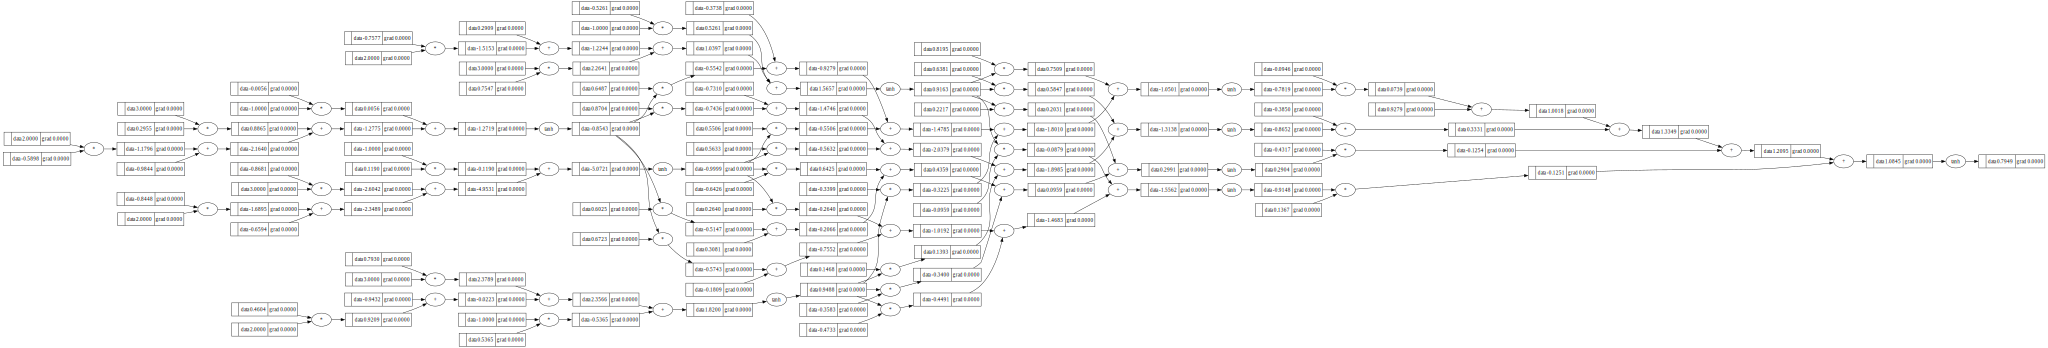

In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
result = n(x)
draw_dot(result)

The visualization of the MLP above is NOT intuitive in the slightest. This is because it just shows the different operations in a flow-like view. You can't just look at it and intuitively know what is part of what neuron. However:
- We know that in this MLP, a neuron's operations entail:
    - Multiplying an input by it's weight
    - Adding these products (3 different subjects to add, as there were 3 inputs and 3 subsequent weights.)
    - Adding the bias
    - Running a tanh activation function on the resulting sum.
- Branching off this, we know that the multiplication of 2 leaf nodes would mean an input being multiplied by it's weight. According to the MLP setup, there should be 3 of these products of 2 leaf nodes per neuron, and in this case, 12 occurences total (3 per neuron, 4 neurons in the first layer).
- Therefore, we know that a tanh signifies the end of a neuron's operation.
    - Therefore, to confirm the size of the MLP, we can count the tanh occurrences. For the above, there should be 4 tanh for the first layer, 4 for the second, and 1 more for the final output layer (4, 4, and 1 neurons per layer respectively).

[(Value(data=0.28567124696698754), 2.0), (Value(data=0.14993492775528994), 3.0)]
[(Value(data=0.8644338915731846), 2.0), (Value(data=0.29652305159971126), 3.0)]
[(Value(data=0.4657637901068481), Value(data=0.12299061706074182)), (Value(data=-0.779696420324026), Value(data=0.9917387760550139))]


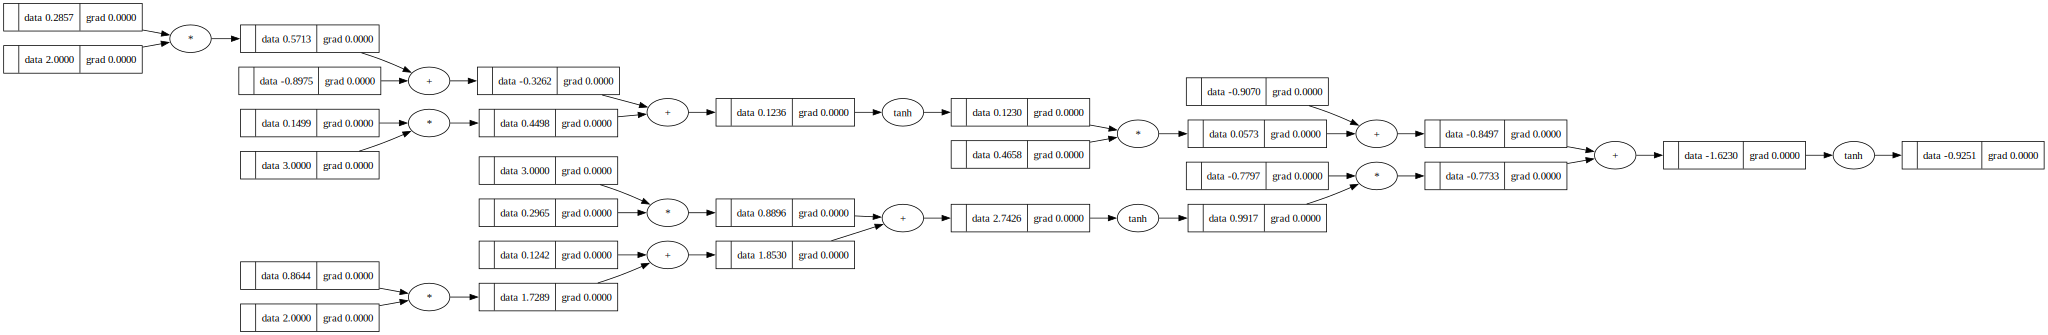

In [220]:
x = [2.0, 3.0]
n = MLP(2, [2, 1])  # 2 layers: [2 neurons, 1 neuron]
result = n(x)
draw_dot(result)